# Dokumentasjon på funksjon for å avstand-score

For å kunne sammenligne resultatene fra foreldreundersøkelsen med avstand fra hjemadresse må man bruke et sammenlignbart poengsystem. Foreldreundersøkelsen gir barnehagene poeng på en skala fra 0-5. Det er naturlig å bruke den samme skalaen for avstand. 

I tillegg er nødvendig å gjøre enda en avgresning. Svarene i foreldreundersøkelsen viser at foreldre i liten grad bruker hele skalaen. I 2026 var den høyste scoren for total tilfredshet 5, mens den laveste var 3,4. Funksjonen vi konstruerer må derfor være lik 5 når avstand er lik 0 og lik 3.4 når avstand går mot uendlig. I praksis burde scoren gå mot 3,4 lenge før avstand når uendelig. Spørsmålet er imidlertid hvor raskt den skal gå mot 3,4. 

Det er ikke selfølgelig hvordan dette skal gjøres, og det finnes mange alternativer. Det nødvendig å bestemme seg for hvilken type funksjon vi skal bruke, og hvor raskt den skal falle. Det siste bestemmes av hvilke parametere vi bruker i funksjonen. 

I dette dokumentet ser jeg nærmere på én type funksjon. Jeg fokuserer i hovedsak på parameteret vi kan fininnstille for å gi funksjonen de egenskapene som er ønskelige. 

In [1]:
%matplotlib inline

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider
import ipympl
from IPython.display import clear_output

In [7]:
df = pd.read_parquet("data/foreldreundersokelse_geo.parquet",
                     engine = "pyarrow")

In [3]:
def plot_avstand(log_k=-4):
    parameter = 10**log_k
    clear_output(wait=True)
    plt.figure(figsize=(8,4))
    x = np.linspace(0, 15000, 15001)
    plt.plot(x, 3.4+(1.6/(1+x*parameter)))
    plt.xlabel("Avstand")
    plt.ylabel("Score")
    plt.title(f"parameter = {parameter:.4f}")
    plt.show()

interact(plot_avstand, log_k=FloatSlider(value=-4, min=-4, max=0, step=0.1, readout_format='.1f', continuous_update=False))

interactive(children=(FloatSlider(value=-4.0, continuous_update=False, description='log_k', max=0.0, min=-4.0,…

<function __main__.plot_avstand(log_k=-4)>

Figuren over plotter funksjonen: 

$f(Avstand) = 3.4 + \frac{1.6}{1+k \cdot Avstand}$

Funksjonen innehar de nødvendige egenskapene vi er ute etter. Når avstand fra hjemadresse er 0, får barnehagen den høyest mulige poengsummen. Ettersom avstanden øker, faller poengsummen. Når $Avstand \to \infty$, går poengsummen mot 3. 

Hvor raskt funksjonen går mot 3 avhenger av parameteret $k$. Større $k$ gjør at poengsummmen går raskere mot 3. Dette kan man se av funksjonens deriverte: $f'(Avstand) = -\frac{2k}{(1+k \cdot Avstand)^2}$. Når $k$ nærmer seg 1, vil bare en liten endringen i avstanden fra hjemadresse resultere i en poengsum nær 3. Den deriverte er plottet i figuren under. Funksjonen stiger ettersom $avstand$ vokser. Når $k$ er større, skjer dette raskere, og når $k = 1$, har vi en Leontiefaktig-funksjon. 

In [4]:
def plot_derivert(log_k=-4):
    parameter = 10**log_k
    clear_output(wait=True)
    plt.figure(figsize=(8,4))
    x = np.linspace(0, 15000, 15001)
    plt.plot(x, -2*parameter/(1+x*parameter)**2)
    plt.xlabel("Avstand")
    plt.ylabel("Score")
    plt.title(f"parameter = {parameter:.4f}")
    plt.show()

interact(plot_derivert, log_k=FloatSlider(value=-4, min=-4, max=0, step=0.1, readout_format='.1f', continuous_update=False))

interactive(children=(FloatSlider(value=-4.0, continuous_update=False, description='log_k', max=0.0, min=-4.0,…

<function __main__.plot_derivert(log_k=-4)>

In [27]:
def avstand_score(avstand, k=0.0003):
    score = 3.4+(1.6/(1+avstand*k))
    return score

In [28]:
df["avstand_score_ny"] = avstand_score(df["Avstand_hjem_m"])

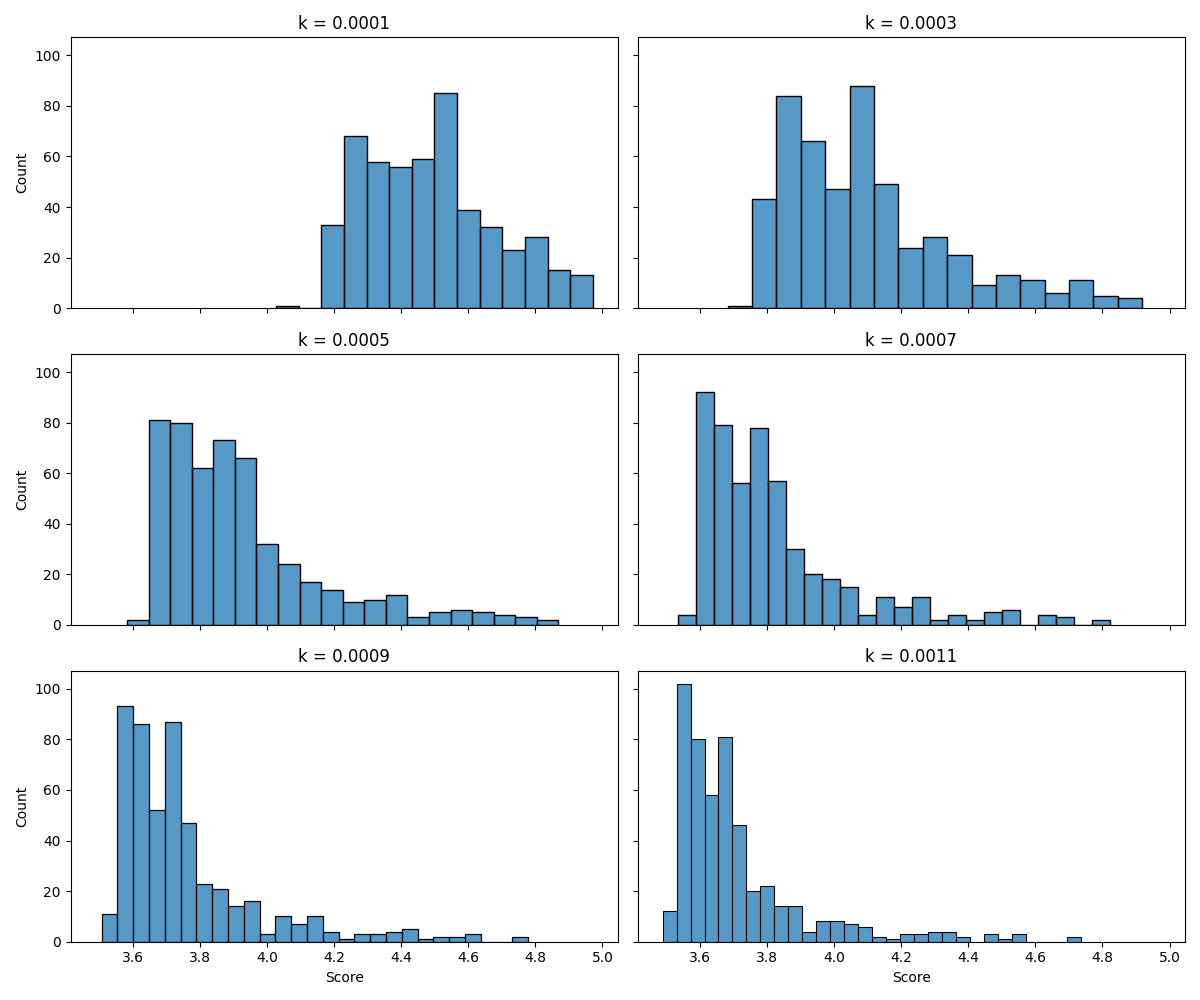

In [40]:
k_verdier = [0.0001, 0.0003, 0.0005, 0.0007, 0.0009, 0.0011]                            
              
fig, axes = plt.subplots(3, 2,
figsize=(12, 10), sharey=True, sharex=True)
axes = axes.flatten()

for ax, k in zip(axes, k_verdier):
  scores = avstand_score(df["Avstand_hjem_m"], k=k)
  sns.histplot(scores, ax=ax)
  ax.set_title(f"k = {k}")
  ax.set_xlabel("Score")

plt.tight_layout()
plt.show()